# **FYP Sales Forecasting Model Building (Product Quantity)**

**Import Module**

All the import module will be written below

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import joblib
from sklearn.preprocessing import LabelEncoder

### Model Training

Read Sales Forecasting Data

In [58]:
product_sales_data = pd.read_csv("Sales Forecasting Data Product Quantity.csv")
product_sales_data['order_purchase_timestamp'] = pd.to_datetime(product_sales_data['order_purchase_timestamp'])
product_sales_data['quantity'] = product_sales_data['quantity'].astype(int)
product_sales_data

,product_id,order_purchase_timestamp,product_category_name,quantity,price,product_weight_g,product_photos_qty
0,00066f42aeeb9f3007548bb9d3f33c38,2017-02-05,perfumery,0,101.65,300.0,6.0
1,00066f42aeeb9f3007548bb9d3f33c38,2017-02-12,perfumery,0,101.65,300.0,6.0
2,00066f42aeeb9f3007548bb9d3f33c38,2017-02-19,perfumery,0,101.65,300.0,6.0
3,00066f42aeeb9f3007548bb9d3f33c38,2017-02-26,perfumery,0,101.65,300.0,6.0
4,00066f42aeeb9f3007548bb9d3f33c38,2017-03-05,perfumery,0,101.65,300.0,6.0
...,...,...,...,...,...,...,...
2609973,fffe9eeff12fcbd74a2f2b007dde0c58,2018-07-29,toys,0,249.99,3900.0,3.0
2609974,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-05,toys,0,249.99,3900.0,3.0
2609975,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-12,toys,0,249.99,3900.0,3.0
2609976,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-19,toys,0,249.99,3900.0,3.0


Encode Categorical Features

In [3]:
le = LabelEncoder()
product_sales_data['category_code'] = product_sales_data['product_category_name'].astype('category').cat.codes

Feature Engineering

In [4]:
def create_features_for_olist(df):
    df = df.copy()
    
    # ensure sorted by product and date
    df = df.sort_values(['product_id', 'order_purchase_timestamp'])
    
    # --- A. Date Components ---
    df['month'] = df['order_purchase_timestamp'].dt.month
    df['week_of_year'] = df['order_purchase_timestamp'].dt.isocalendar().week.astype(int)
    
    # Black Friday Logic
    df['is_black_friday'] = df['week_of_year'].apply(lambda x: 1 if x == 47 else 0)
    
    # --- B. Lag Features (History) ---
    group = df.groupby('product_id')['quantity']
    
    df['lag_1_week'] = group.shift(1)
    df['lag_2_weeks'] = group.shift(2)
    df['lag_4_weeks'] = group.shift(4)

    # --- C. Rolling & Expanding Features (Trends) ---
    df['rolling_mean_4w'] = group.shift(1).rolling(window=4).mean()
    df['expanding_mean'] = group.shift(1).expanding().mean().fillna(0)
    
    # Fill NaN lags
    lag_cols = ['lag_1_week', 'lag_2_weeks', 'lag_4_weeks', 'rolling_mean_4w']
    df[lag_cols] = df[lag_cols].fillna(0)
    
    # --- D. Sales Velocity ---
    has_sales = (group.shift(1) > 0).astype(int)
    df['sales_velocity_12w'] = has_sales.rolling(window=12).sum().fillna(0)

    # --- E. Price & Category Dynamics (Keep these, they are dynamic) ---
    group_price = df.groupby('product_id')['price']
    df['avg_price_lag_4w'] = group_price.shift(1).rolling(window=4).mean()
    df['price_momentum'] = df['price'] / df['avg_price_lag_4w']
    df['price_momentum'] = df['price_momentum'].fillna(1.0)
    
    category_trends = df.groupby(['product_category_name', 'order_purchase_timestamp'])['quantity'].sum().reset_index()
    category_trends = category_trends.rename(columns={'quantity': 'category_weekly_total'})
    category_trends['order_purchase_timestamp'] = category_trends['order_purchase_timestamp'] + pd.Timedelta(weeks=1)
    df = df.merge(category_trends, on=['product_category_name', 'order_purchase_timestamp'], how='left')
    df['category_weekly_total'] = df['category_weekly_total'].fillna(0)
    
    # Calculate the global average sales for each category (using expanding mean to avoid leakage)
    # Group by Category -> Calculate Expanding Mean of Quantity -> Shift 1
    df['category_target_encoding'] = df.groupby('product_category_name')['quantity'] \
        .transform(lambda x: x.shift(1).expanding().mean()) \
        .fillna(0)
    
    return df

In [5]:
product_sales_data = create_features_for_olist(product_sales_data)
product_sales_data

,product_id,order_purchase_timestamp,product_category_name,quantity,price,product_weight_g,product_photos_qty,category_code,month,week_of_year,...,lag_1_week,lag_2_weeks,lag_4_weeks,rolling_mean_4w,expanding_mean,sales_velocity_12w,avg_price_lag_4w,price_momentum,category_weekly_total,category_target_encoding
0,00066f42aeeb9f3007548bb9d3f33c38,2017-02-05,perfumery,0,101.65,300.0,6.0,14,2,5,...,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,1.0,0.0,0.000000
1,00066f42aeeb9f3007548bb9d3f33c38,2017-02-12,perfumery,0,101.65,300.0,6.0,14,2,6,...,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,1.0,17.0,0.000000
2,00066f42aeeb9f3007548bb9d3f33c38,2017-02-19,perfumery,0,101.65,300.0,6.0,14,2,7,...,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,1.0,14.0,0.000000
3,00066f42aeeb9f3007548bb9d3f33c38,2017-02-26,perfumery,0,101.65,300.0,6.0,14,2,8,...,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,1.0,8.0,0.000000
4,00066f42aeeb9f3007548bb9d3f33c38,2017-03-05,perfumery,0,101.65,300.0,6.0,14,3,9,...,0.0,0.0,0.0,0.0,0.000000,0.0,101.65,1.0,7.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2609973,fffe9eeff12fcbd74a2f2b007dde0c58,2018-07-29,toys,0,249.99,3900.0,3.0,19,7,30,...,0.0,0.0,0.0,0.0,0.041746,1.0,249.99,1.0,42.0,0.035617
2609974,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-05,toys,0,249.99,3900.0,3.0,19,8,31,...,0.0,0.0,0.0,0.0,0.041746,1.0,249.99,1.0,40.0,0.035617
2609975,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-12,toys,0,249.99,3900.0,3.0,19,8,32,...,0.0,0.0,0.0,0.0,0.041745,1.0,249.99,1.0,42.0,0.035616
2609976,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-19,toys,0,249.99,3900.0,3.0,19,8,33,...,0.0,0.0,0.0,0.0,0.041745,0.0,249.99,1.0,52.0,0.035616


Data Splitting

In [6]:
# Split data (e.g., use data before 2018-06-01 for training)
split_date = '2018-06-01'

train = product_sales_data.loc[product_sales_data['order_purchase_timestamp'] < split_date]
test = product_sales_data.loc[product_sales_data['order_purchase_timestamp'] >= split_date]

print("Train set date range:")
print("Min:", train['order_purchase_timestamp'].min())
print("Max:", train['order_purchase_timestamp'].max())

print("\nTest set date range:")
print("Min:", test['order_purchase_timestamp'].min())
print("Max:", test['order_purchase_timestamp'].max())

Train set date range:
Min: 2017-02-05 00:00:00
Max: 2018-05-27 00:00:00

Test set date range:
Min: 2018-06-03 00:00:00
Max: 2018-08-26 00:00:00


Prepare X & Y train test

In [7]:
features = [
    'price',
    'price_momentum', 
    'category_code', 
    'month', 
    'week_of_year', 
    'is_black_friday',
    'lag_1_week', 
    'lag_2_weeks',
    'lag_4_weeks', 
    'rolling_mean_4w',
    'category_weekly_total',
    'sales_velocity_12w',
    'expanding_mean',
    'category_target_encoding'
]
target = 'quantity'

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

**Linear Regression**

In [8]:
model = LinearRegression(n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Linear Regression Evaluation Metrics:
+--------------------------------+-----------+
| Metric                         |     Score |
+================================+===========+
| Mean Absolute Error (MAE)      | 0.0849584 |
+--------------------------------+-----------+
| Root Mean Squared Error (RMSE) | 0.320569  |
+--------------------------------+-----------+
| R² Score                       | 0.130771  |
+--------------------------------+-----------+


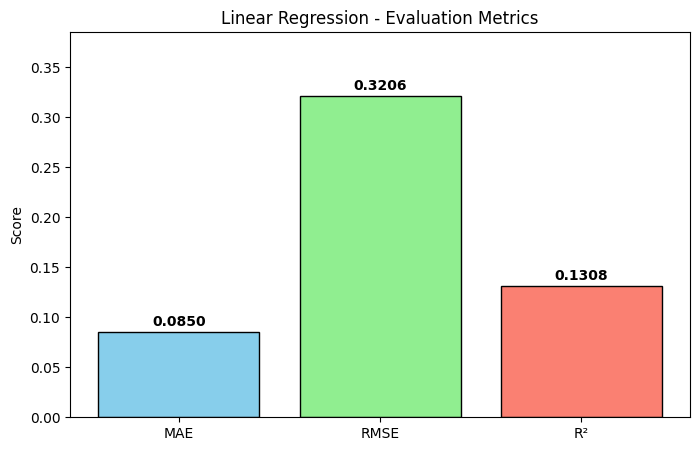

In [9]:
lr_mae = mean_absolute_error(y_test, y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_r2 = r2_score(y_test, y_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", lr_mae],
    ["Root Mean Squared Error (RMSE)", lr_rmse],
    ["R² Score", lr_r2]
]

print("Linear Regression Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot the metrics
metrics = ["MAE", "RMSE", "R²"]
scores = [lr_mae, lr_rmse ,lr_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Linear Regression - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**Random Forest**

In [10]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Random Forest Evaluation Metrics:
+--------------------------------+----------+
| Metric                         |    Score |
+================================+==========+
| Mean Absolute Error (MAE)      | 0.076467 |
+--------------------------------+----------+
| Root Mean Squared Error (RMSE) | 0.312598 |
+--------------------------------+----------+
| R² Score                       | 0.173462 |
+--------------------------------+----------+


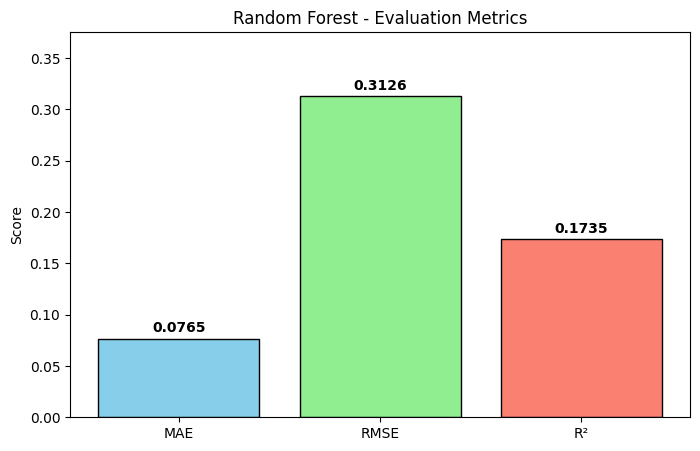

In [12]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", rf_mae],
    ["Root Mean Squared Error (RMSE)", rf_rmse],
    ["R² Score", rf_r2]
]

print("Random Forest Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "R²"]
scores = [rf_mae, rf_rmse, rf_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Random Forest - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**XGBoost**

In [13]:
reg_xgb = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50,objective='count:poisson', random_state=42)
reg_xgb.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

xgb_pred = reg_xgb.predict(X_test)

[0]	validation_0-poisson-nloglik:0.17652	validation_1-poisson-nloglik:0.21724
[76]	validation_0-poisson-nloglik:0.12961	validation_1-poisson-nloglik:0.17168


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

XGBoost Evaluation Metrics:
+--------------------------------+-----------+
| Metric                         |     Score |
+================================+===========+
| Mean Absolute Error (MAE)      | 0.0762226 |
+--------------------------------+-----------+
| Root Mean Squared Error (RMSE) | 0.30148   |
+--------------------------------+-----------+
| R² Score                       | 0.23121   |
+--------------------------------+-----------+


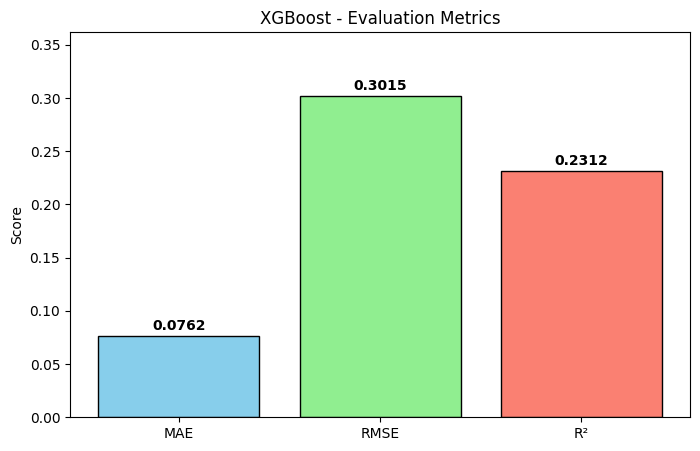

In [14]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", xgb_mae],
    ["Root Mean Squared Error (RMSE)", xgb_rmse],
    ["R² Score", xgb_r2]
]

print("XGBoost Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "R²"]
scores = [xgb_mae, xgb_rmse, xgb_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("XGBoost - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**LightGBM**

In [15]:
cat_features = ['category_code', 'month', 'week_of_year', 'is_black_friday']

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=cat_features)

params = {
    'objective': 'poisson',
    'metric': 'rmse',
    'learning_rate': 0.01, 
    'num_leaves': 15,      
    'min_child_samples': 50, 
    'reg_alpha': 1.0,      
    'reg_lambda': 1.0,     
    'verbose': -1
}

lgbm_model = lgb.train(
    params, 
    train_data, 
    num_boost_round=1000, 
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
)

lgbm_pred = lgbm_model.predict(X_test)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.318307
[200]	valid_0's rmse: 0.309093
[300]	valid_0's rmse: 0.30609
[400]	valid_0's rmse: 0.305481
Early stopping, best iteration is:
[403]	valid_0's rmse: 0.305478


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

LightGBM Evaluation Metrics:
+--------------------------------+-----------+
| Metric                         |     Score |
+================================+===========+
| Mean Absolute Error (MAE)      | 0.0762534 |
+--------------------------------+-----------+
| Root Mean Squared Error (RMSE) | 0.305478  |
+--------------------------------+-----------+
| R² Score                       | 0.210686  |
+--------------------------------+-----------+


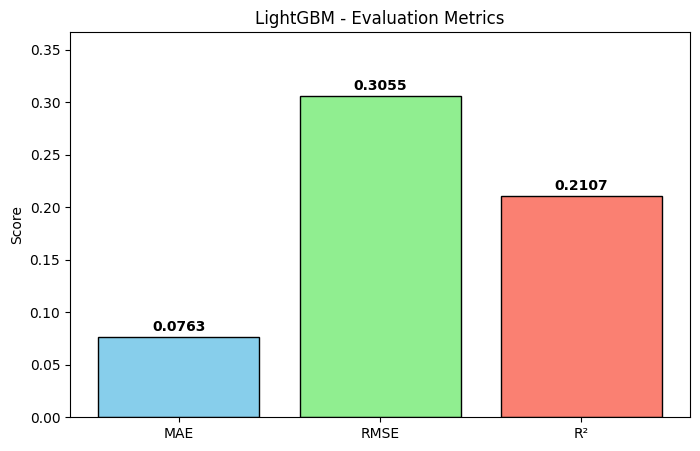

In [16]:
lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
lgbm_r2 = r2_score(y_test, lgbm_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", lgbm_mae],
    ["Root Mean Squared Error (RMSE)", lgbm_rmse],
    ["R² Score", lgbm_r2]
]

print("LightGBM Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "R²"]
scores = [lgbm_mae, lgbm_rmse, lgbm_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("LightGBM - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

### Hyperparameter Tuning

**Time Series Split**

In [17]:
tscv = TimeSeriesSplit(n_splits=5)

**Linear Regression**

In [18]:
lr_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

lr_search = GridSearchCV(
    estimator=LinearRegression(n_jobs=-1),
    param_grid=lr_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

lr_search.fit(X_train, y_train)

print("Best LR parameters:", lr_search.best_params_)
print("Best LR Score (Negative RMSE):", lr_search.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best LR parameters: {'fit_intercept': False, 'positive': False}
Best LR Score (Negative RMSE): -0.2971966800302922


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Tuned Linear Regression Evaluation Metrics:
+--------------------------------+-----------+
| Metric                         |     Score |
+================================+===========+
| Mean Absolute Error (MAE)      | 0.0849566 |
+--------------------------------+-----------+
| Root Mean Squared Error (RMSE) | 0.320569  |
+--------------------------------+-----------+
| R² Score                       | 0.130773  |
+--------------------------------+-----------+


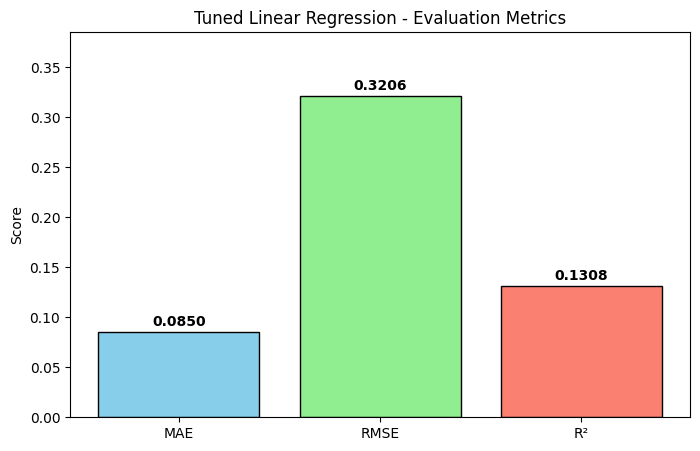

In [19]:
best_lr_model = lr_search.best_estimator_
best_lr_y_pred = best_lr_model.predict(X_test)

best_lr_mae = mean_absolute_error(y_test, best_lr_y_pred)
best_lr_rmse = np.sqrt(mean_squared_error(y_test, best_lr_y_pred))
best_lr_r2 = r2_score(y_test, best_lr_y_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", best_lr_mae],
    ["Root Mean Squared Error (RMSE)", best_lr_rmse],
    ["R² Score", best_lr_r2]
]

print("Tuned Linear Regression Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "R²"]
scores = [best_lr_mae, best_lr_rmse, best_lr_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned Linear Regression - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

Performance Comparison

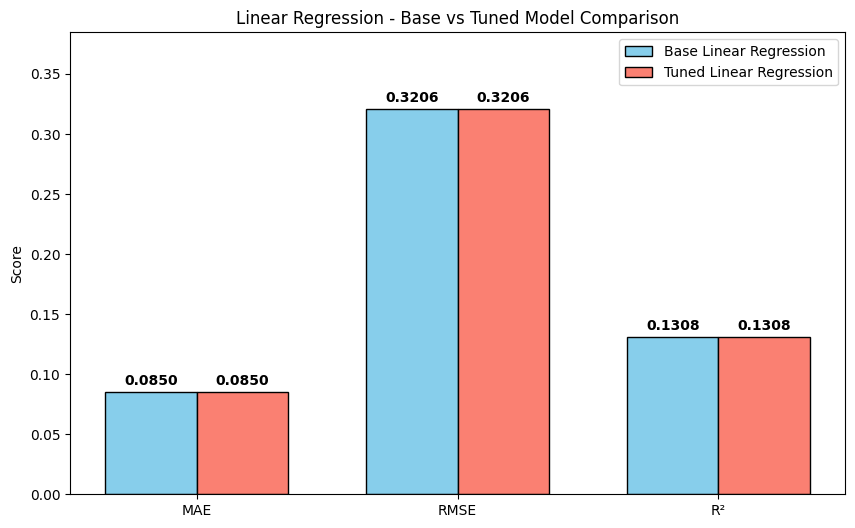

In [20]:
metrics = ["MAE", "RMSE", "R²"]
base_scores = [lr_mae, lr_rmse, lr_r2]
tuned_scores = [best_lr_mae, best_lr_rmse, best_lr_r2]

x = np.arange(len(metrics))  # positions for groups
width = 0.35  # width of each bar

plt.figure(figsize=(10,6))

# Plot bars
bars1 = plt.bar(x - width/2, base_scores, width, label='Base Linear Regression', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, tuned_scores, width, label='Tuned Linear Regression', color='salmon', edgecolor='black')

# Labels and title
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Linear Regression - Base vs Tuned Model Comparison")
plt.ylim(0, max(max(base_scores), max(tuned_scores)) * 1.2)  # add space for labels
plt.legend()

# Add values on top
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**Random Forest**

In [11]:
rf_grid = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [5, 10, 15, None],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4],    
    'max_features': ['sqrt', 'log2', 0.5, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_grid,
    n_iter=30, 
    cv=tscv,  
    scoring='neg_root_mean_squared_error',
    random_state=42, 
    n_jobs=-1, 
    verbose=1
)

# 3. Fit
print("Tuning Random Forest...")
rf_search.fit(X_train, y_train)

print(f"Best RF Params: {rf_search.best_params_}")
print(f"Best RF Score (Negative RMSE): {rf_search.best_score_}")

Tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10}
Best RF Score (Negative RMSE): -0.2888069287725801


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Tuned Random Forest Evaluation Metrics:
+--------------------------------+----------+
| Metric                         |    Score |
+================================+==========+
| Mean Absolute Error (MAE)      | 0.075967 |
+--------------------------------+----------+
| Root Mean Squared Error (RMSE) | 0.306914 |
+--------------------------------+----------+
| R² Score                       | 0.203248 |
+--------------------------------+----------+


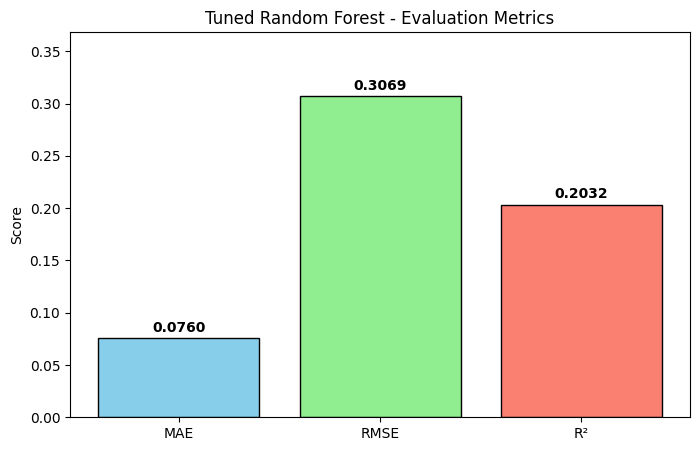

In [ ]:
best_rf_model = rf_search.best_estimator_
best_rf_y_pred = best_rf_model.predict(X_test)

best_rf_mae = mean_absolute_error(y_test, best_rf_y_pred)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_y_pred))
best_rf_r2 = r2_score(y_test, best_rf_y_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", best_rf_mae],
    ["Root Mean Squared Error (RMSE)", best_rf_rmse],
    ["R² Score", best_rf_r2]
]

print("Tuned Random Forest Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "R²"]
scores = [best_rf_mae, best_rf_rmse, best_rf_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned Random Forest - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

Performance Comparison

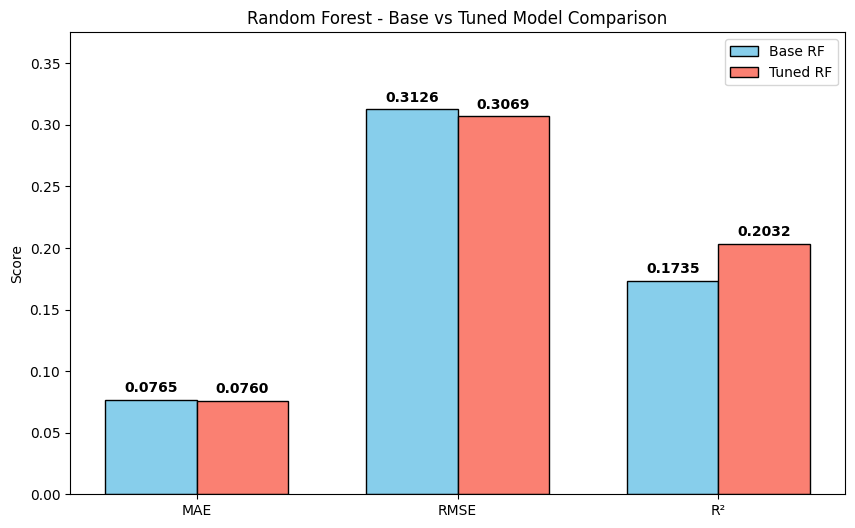

In [23]:
metrics = ["MAE", "RMSE", "R²"]
base_scores = [rf_mae, rf_rmse, rf_r2]
tuned_scores = [best_rf_mae, best_rf_rmse, best_rf_r2]

x = np.arange(len(metrics))  # positions for groups
width = 0.35  # width of each bar

plt.figure(figsize=(10,6))

# Plot bars
bars1 = plt.bar(x - width/2, base_scores, width, label='Base RF', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, tuned_scores, width, label='Tuned RF', color='salmon', edgecolor='black')

# Labels and title
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Random Forest - Base vs Tuned Model Comparison")
plt.ylim(0, max(max(base_scores), max(tuned_scores))*1.2)  # extra space for labels
plt.legend()

# Add values on top
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**XGBoost**

In [24]:
xgb_grid = {
    'n_estimators': [500, 1000, 1500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_lambda': [0.1, 1.0, 10.0],
    'reg_alpha': [0.0, 0.1, 1.0]
}

# 2. Setup Search
xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='count:poisson', random_state=42, n_jobs=-1),
    param_distributions=xgb_grid,
    n_iter=30,
    cv=tscv,
    random_state=42,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# 3. Fit
print("Tuning XGBoost...")
xgb_search.fit(X_train, y_train)

print(f"Best XGB Params: {xgb_search.best_params_}")
print(f"Best XGB Score (Negative RMSE): {xgb_search.best_score_}")

Tuning XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB Params: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best XGB Score (Negative RMSE): -0.29697640538215636


Train With Best Parameter

In [30]:
best_params = xgb_search.best_params_
final_model = xgb.XGBRegressor(
    **best_params,
    early_stopping_rounds=50,
    objective='count:poisson',
    random_state=42
)

final_model.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

best_xgb_y_pred = final_model.predict(X_test)

[0]	validation_0-poisson-nloglik:0.18085	validation_1-poisson-nloglik:0.22193
[100]	validation_0-poisson-nloglik:0.13762	validation_1-poisson-nloglik:0.17440
[200]	validation_0-poisson-nloglik:0.13302	validation_1-poisson-nloglik:0.17198
[278]	validation_0-poisson-nloglik:0.13245	validation_1-poisson-nloglik:0.17195


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Tuned XGBoost Evaluation Metrics:
+--------------------------------+-----------+
| Metric                         |     Score |
+================================+===========+
| Mean Absolute Error (MAE)      | 0.0774133 |
+--------------------------------+-----------+
| Root Mean Squared Error (RMSE) | 0.304804  |
+--------------------------------+-----------+
| R² Score                       | 0.214161  |
+--------------------------------+-----------+


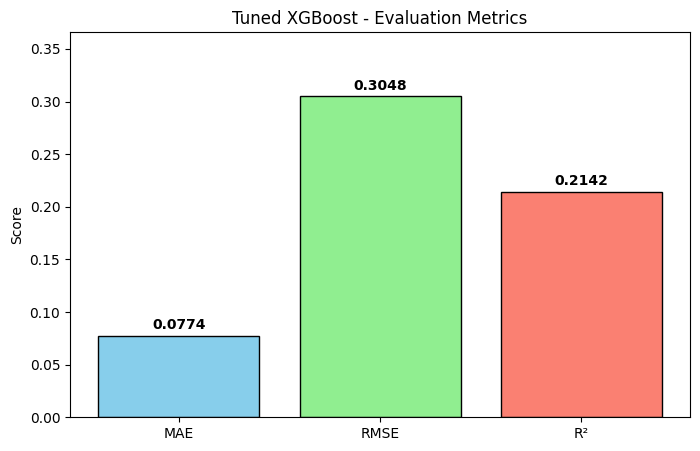

In [31]:
best_xgb_mae = mean_absolute_error(y_test, best_xgb_y_pred)
best_xgb_rmse = np.sqrt(mean_squared_error(y_test, best_xgb_y_pred))
best_xgb_r2 = r2_score(y_test, best_xgb_y_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", best_xgb_mae],
    ["Root Mean Squared Error (RMSE)", best_xgb_rmse],
    ["R² Score", best_xgb_r2]
]

print("Tuned XGBoost Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "R²"]
scores = [best_xgb_mae, best_xgb_rmse, best_xgb_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned XGBoost - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

Performance Comparison

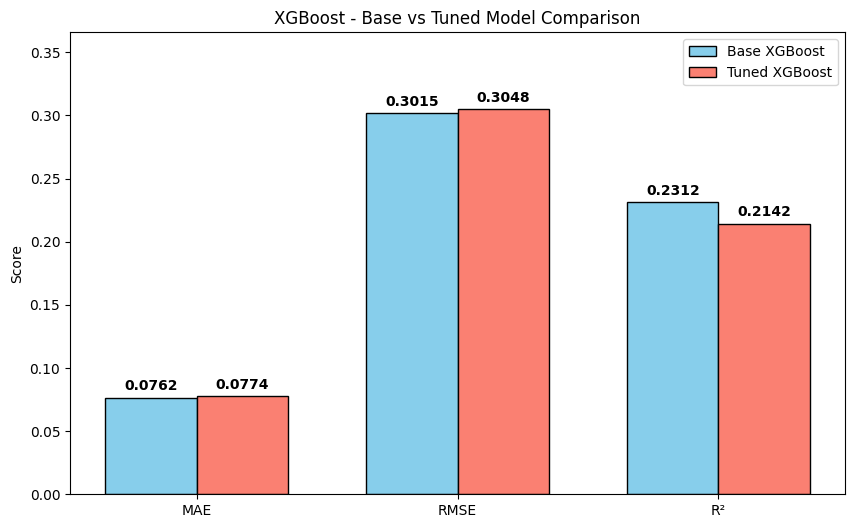

In [32]:
metrics = ["MAE", "RMSE", "R²"]
base_scores = [xgb_mae, xgb_rmse, xgb_r2]
tuned_scores = [best_xgb_mae, best_xgb_rmse, best_xgb_r2]

x = np.arange(len(metrics))  # positions for groups
width = 0.35  # width of each bar

plt.figure(figsize=(10,6))

# Plot bars
bars1 = plt.bar(x - width/2, base_scores, width, label='Base XGBoost', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, tuned_scores, width, label='Tuned XGBoost', color='salmon', edgecolor='black')

# Labels and title
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("XGBoost - Base vs Tuned Model Comparison")
plt.ylim(0, max(max(base_scores), max(tuned_scores)) * 1.2)  # extra space for labels
plt.legend()

# Add values on top
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**LightGBM**

In [33]:
cat_cols = ['category_code', 'month', 'week_of_year', 'is_black_friday']
X_train_lgb = X_train.copy()
for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')

static_params = {
    'objective': 'poisson',
    'metric': 'rmse',
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

lgb_grid = {
    'n_estimators': [500, 1000, 1500],
    'num_leaves': [15, 31, 63],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [20, 50, 100],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0.0, 0.1, 1.0, 5.0], 
    'reg_lambda': [0.0, 1.0, 5.0, 10.0]
}

# 2. Setup Search
lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(**static_params),
    param_distributions=lgb_grid,
    n_iter=30,
    cv=tscv,
    random_state= 42,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# 3. Fit
print("Tuning LightGBM...")
lgb_search.fit(X_train_lgb, y_train)

print(f"Best LightGBM Params: {lgb_search.best_params_}")
print(f"Best LightGBM Score (Negative RMSE): {lgb_search.best_score_}")

Tuning LightGBM...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best LightGBM Params: {'reg_lambda': 10.0, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 1000, 'min_child_samples': 50, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best LightGBM Score (Negative RMSE): -0.28833991616399623


Train With Best Parameter

In [34]:
tuned_params = lgb_search.best_params_
final_params = {**static_params, **tuned_params}

cat_features = ['category_code', 'month', 'week_of_year', 'is_black_friday']

train_data = lgb.Dataset(X_train, label=y_train, params=final_params,  categorical_feature=cat_features)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, params=final_params,  categorical_feature=cat_features)

num_rounds = final_params.pop('n_estimators', 1000)

final_lgbm_model = lgb.train(final_params, train_data, num_boost_round=num_rounds, 
                       valid_sets=[test_data],
                       callbacks=[lgb.early_stopping(stopping_rounds=50)])

best_lgbm_y_pred = final_lgbm_model.predict(X_test)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[456]	valid_0's rmse: 0.304522


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Tuned LightGBM Evaluation Metrics:
+--------------------------------+-----------+
| Metric                         |     Score |
+================================+===========+
| Mean Absolute Error (MAE)      | 0.0757312 |
+--------------------------------+-----------+
| Root Mean Squared Error (RMSE) | 0.304522  |
+--------------------------------+-----------+
| R² Score                       | 0.215618  |
+--------------------------------+-----------+


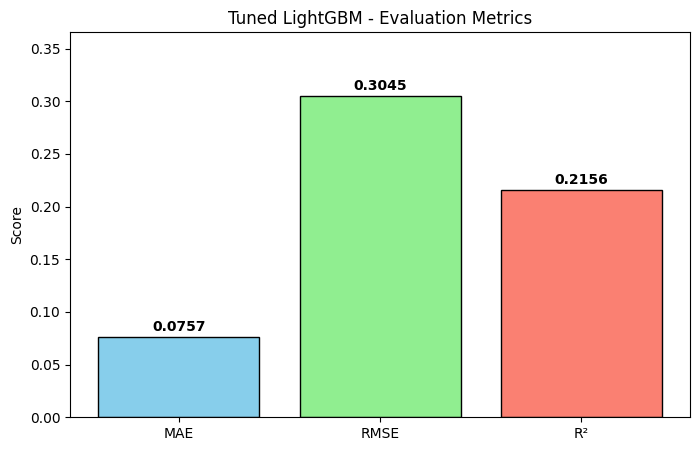

In [35]:
best_lgbm_mae = mean_absolute_error(y_test, best_lgbm_y_pred)
best_lgbm_rmse = np.sqrt(mean_squared_error(y_test, best_lgbm_y_pred))
best_lgbm_r2 = r2_score(y_test, best_lgbm_y_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", best_lgbm_mae],
    ["Root Mean Squared Error (RMSE)", best_lgbm_rmse],
    ["R² Score", best_lgbm_r2]
]

print("Tuned LightGBM Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot the metrics
metrics = ["MAE", "RMSE","R²"]
scores = [best_lgbm_mae, best_lgbm_rmse, best_lgbm_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned LightGBM - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

Performance Comparison

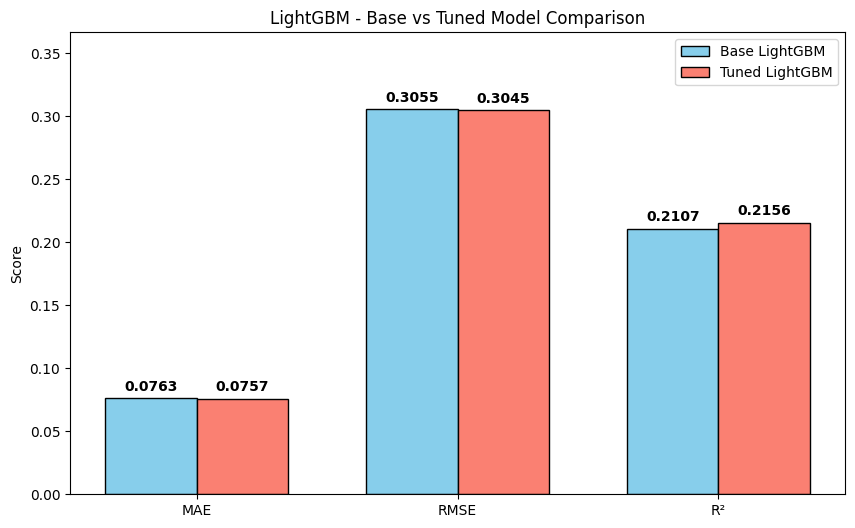

In [36]:
metrics = ["MAE", "RMSE", "R²"]
base_scores = [lgbm_mae, lgbm_rmse, lgbm_r2]
tuned_scores = [best_lgbm_mae, best_lgbm_rmse, best_lgbm_r2]

x = np.arange(len(metrics))  # positions for groups
width = 0.35  # width of each bar

plt.figure(figsize=(10,6))

# Plot bars
bars1 = plt.bar(x - width/2, base_scores, width, label='Base LightGBM', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, tuned_scores, width, label='Tuned LightGBM', color='salmon', edgecolor='black')

# Labels and title
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("LightGBM - Base vs Tuned Model Comparison")
plt.ylim(0, max(max(base_scores), max(tuned_scores)) * 1.2)  # extra space for labels
plt.legend()

# Add values on top
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**Best Model Performance Comparison Chart**

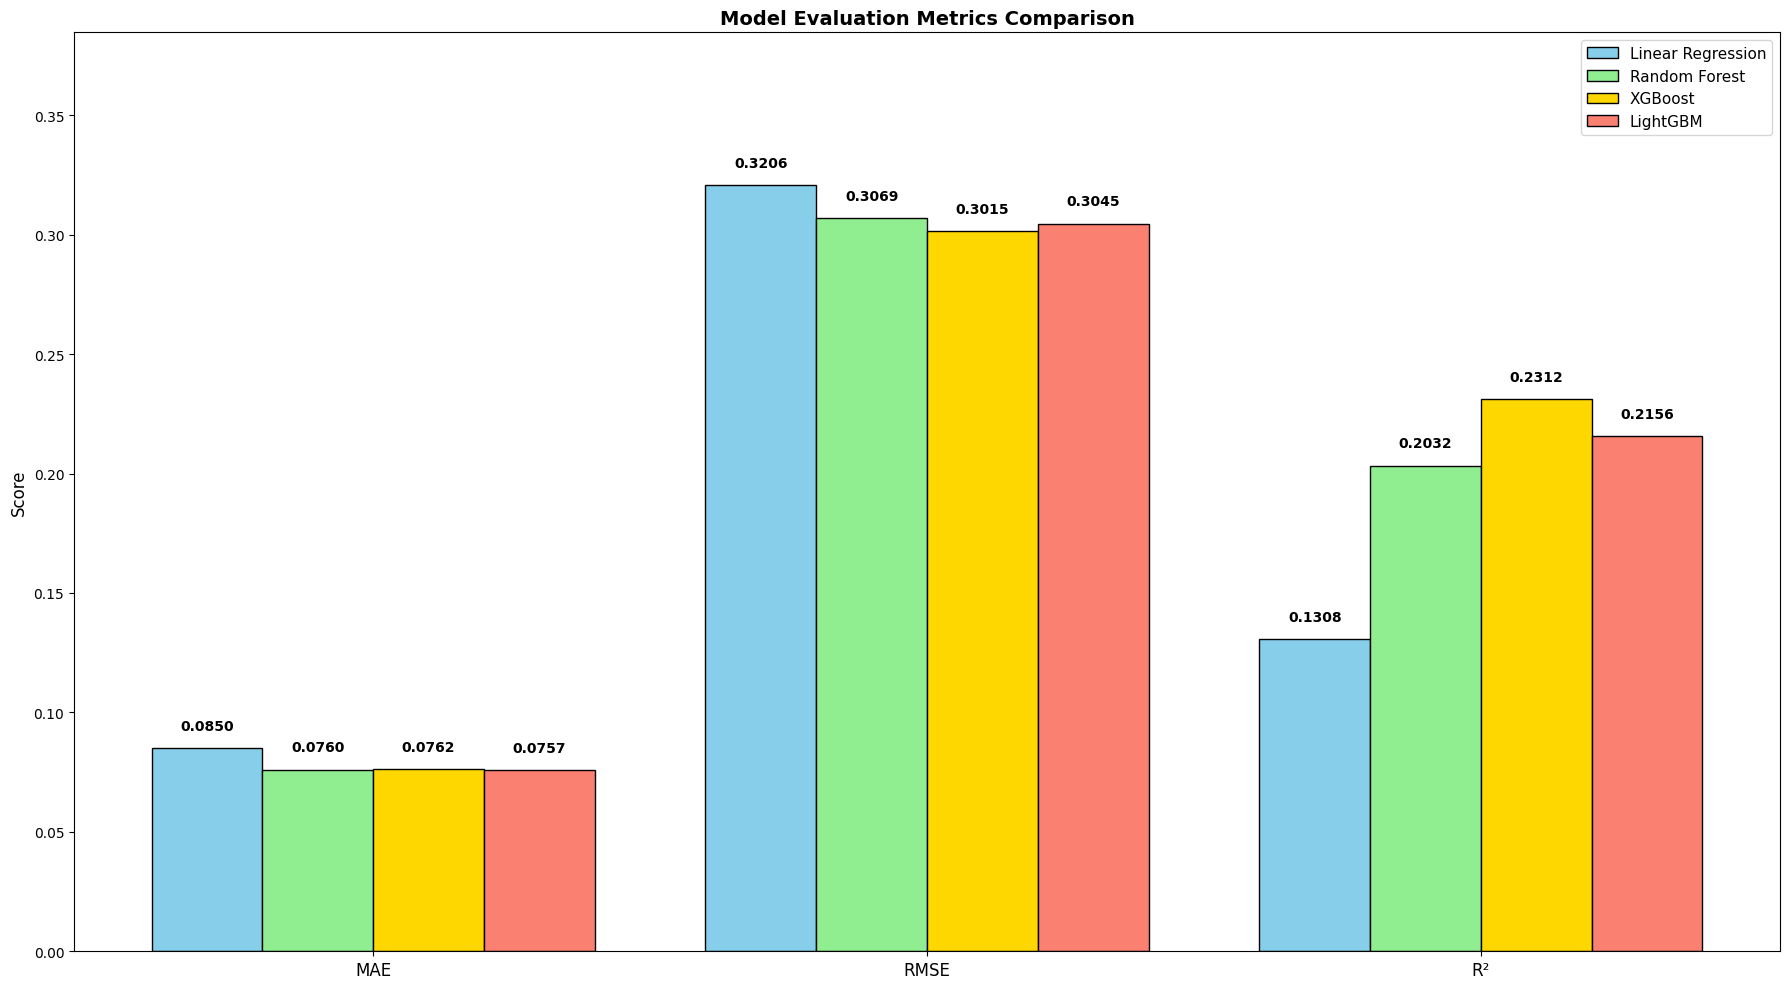

In [38]:
metrics = ["MAE", "RMSE", "R²"]
lr_scores   = [best_lr_mae, best_lr_rmse, best_lr_r2]
rf_scores   = [best_rf_mae, best_rf_rmse, best_rf_r2]
xgb_scores  = [xgb_mae, xgb_rmse, xgb_r2]
lgbm_scores = [best_lgbm_mae, best_lgbm_rmse, best_lgbm_r2]

x = np.arange(len(metrics))
width = 0.2  # slightly narrower bars

plt.figure(figsize=(18, 10))

# Plot bars
bars1 = plt.bar(x - 1.5*width, lr_scores,   width, label="Linear Regression", color="skyblue", edgecolor='black')
bars2 = plt.bar(x - 0.5*width, rf_scores,   width, label="Random Forest",     color="lightgreen", edgecolor='black')
bars3 = plt.bar(x + 0.5*width, xgb_scores,  width, label="XGBoost",           color="gold", edgecolor='black')
bars4 = plt.bar(x + 1.5*width, lgbm_scores, width, label="LightGBM",          color="salmon", edgecolor='black')

# Formatting
plt.ylim(0, max(max(lr_scores), max(rf_scores), max(xgb_scores), max(lgbm_scores)) * 1.2)
plt.xticks(x, metrics, fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Model Evaluation Metrics Comparison", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)

# Add value labels
all_bars = [bars1, bars2, bars3, bars4]
for bars in all_bars:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*plt.ylim()[1],
                 f"{height:.4f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Best Model Ratio Evaluation

In [39]:
total_actual = y_test.sum()
total_predicted = xgb_pred.sum()

ratio = total_predicted / total_actual
print(f"Ratio: {ratio:.2f}")

Ratio: 0.92


Forecasting For Next Month

In [46]:
# --- PREP: Ensure full_history is sorted ---
full_history = pd.concat([train, test]).sort_values(['product_id', 'order_purchase_timestamp'])

# Define the Forecasting Horizon
weeks_to_predict = 4
future_predictions = []

print(f"Starting Recursive Forecast for {weeks_to_predict} weeks...")

for i in range(weeks_to_predict):
    # --- A. Create the 'Next Week' Skeleton ---
    last_date = full_history['order_purchase_timestamp'].max()
    next_date = last_date + pd.Timedelta(weeks=1)
    
    print(f"Predicting Week {i+1}: {next_date.date()}...")
    
    unique_products = full_history['product_id'].unique()
    next_week_df = pd.DataFrame({
        'product_id': unique_products,
        'order_purchase_timestamp': next_date,
        'quantity': np.nan 
    })
    
    # --- FIX 1: Add 'product_category_name' to static info ---
    # Without this, the new week doesn't know its category, and feature engineering fails
    static_cols = ['product_id', 'price', 'category_code', 'product_weight_g', 'product_photos_qty', 'product_category_name']
    
    # Get the last known static details for each product
    static_info = full_history.drop_duplicates('product_id', keep='last')[static_cols]
    
    next_week_df = next_week_df.merge(static_info, on='product_id', how='left')
    
    # --- B. Append to History ---
    temp_df = pd.concat([full_history, next_week_df], axis=0)
    
    # --- FIX 2: Drop the conflicting column before Feature Engineering ---
    # This prevents the '_x' and '_y' merge error
    if 'category_weekly_total' in temp_df.columns:
        temp_df = temp_df.drop(columns=['category_weekly_total'])
    
    # --- Run Feature Engineering ---
    temp_df = create_features_for_olist(temp_df)
    
    # --- C. Predict ---
    rows_to_predict = temp_df[temp_df['order_purchase_timestamp'] == next_date]
    X_future = rows_to_predict[features]
    
    # Make Prediction (Predictions are floats like 0.4, 1.2 due to Poisson)
    current_pred = reg_xgb.predict(X_future)
    
    # --- D. Save & Loop ---
    # Assign prediction to the skeleton dataframe
    next_week_df['quantity'] = current_pred
    
    # Add to history so the next loop can use it as a 'Lag'
    full_history = pd.concat([full_history, next_week_df], axis=0)
    
    future_predictions.append(next_week_df)

print("Forecasting Complete!")

Starting Recursive Forecast for 4 weeks...
Predicting Week 1: 2018-09-02...
Predicting Week 2: 2018-09-09...
Predicting Week 3: 2018-09-16...
Predicting Week 4: 2018-09-23...
Forecasting Complete!


In [55]:
# 1. Combine all 4 weeks
future_df = pd.concat(future_predictions)

# 2. Aggregate by Product
monthly_forecast = future_df.groupby(['product_id', 'product_category_name']).agg({
    'quantity': 'sum',           
    'order_purchase_timestamp': 'min' 
}).rename(columns={'quantity': 'predicted_monthly_demand_in_decimal'}).reset_index()

# 3. Add Readable Names (Optional, if you have the product names)
# If you have a 'product_category_name' mapping, merge it here.

# 4. Clean up
# Round to 2 decimals for readability (or nearest integer if you prefer)
monthly_forecast['predicted_monthly_demand_in_decimal'] = monthly_forecast['predicted_monthly_demand_in_decimal'].round(2)

monthly_forecast['predicted_monthly_demand'] = np.ceil(monthly_forecast['predicted_monthly_demand_in_decimal']).astype(int)

# Sort by highest demand
monthly_forecast = monthly_forecast.sort_values('predicted_monthly_demand', ascending=False)

monthly_forecast

,product_id,product_category_name,predicted_monthly_demand_in_decimal,order_purchase_timestamp,predicted_monthly_demand
20927,a92930c327948861c015c919a0bcb4a8,watches_gifts,21.520000,2018-09-02,22
8026,3fbc0ef745950c7932d5f2a446189725,health_beauty,19.940001,2018-09-02,20
23263,bb50f2e236e5eea0100680137654686c,health_beauty,19.160000,2018-09-02,20
14422,73326828aa5efe1ba096223de496f596,Other,17.700001,2018-09-02,18
2599,145978af3e89b318be0b717a0953649a,computers_accessories,12.460000,2018-09-02,13
...,...,...,...,...,...
10685,552a2a10932c4abaff715fe6a4d61280,consoles_games,0.140000,2018-09-02,1
10684,5528209b7e7d4dd862211e10377355d5,furniture_decor,0.390000,2018-09-02,1
10683,55279b0710ffb17d56db631cb318c47a,furniture_decor,0.170000,2018-09-02,1
10682,5526b1ae9ab2688cf600783cece249df,computers_accessories,0.250000,2018-09-02,1


Prepare Stock Level Classification Data -- Early Version

In [57]:
product_df = pd.read_csv("Product Data.csv")
product_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,quantity
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0,1
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,1
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0,1
3,cef67bcfe19066a932b7673e239eb23d,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0,1
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0,1
...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,furniture_decor,45.0,67.0,2.0,12300.0,40.0,40.0,40.0,33
32947,bf4538d88321d0fd4412a93c974510e6,construction_tools_lights,41.0,971.0,1.0,1700.0,16.0,19.0,16.0,2
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,bed_bath_table,50.0,799.0,1.0,1400.0,27.0,7.0,27.0,5
32949,83808703fc0706a22e264b9d75f04a2e,computers_accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0,7
